In [ ]:
import pulp
import pandas as pd

# 1. Khởi tạo dữ liệu với tên vùng đầy đủ từ API
regions = [
    "Trung du miền núi phía Bắc",
    "Đồng bằng sông Hồng",
    "Bắc Trung Bộ và Duyên hải Trung Bộ",
    "Tây Nguyên",
    "Đông Nam Bộ",
    "Đồng bằng sông Cửu Long"
]
items = ['Hạ tầng số', 'CĐS doanh nghiệp', 'Năng lực AI', 'Nhân lực số']

# Map lại logic viết tắt sang tên đầy đủ để mapping beta
reg_map = {
    "Trung du miền núi phía Bắc": 'NMM',
    "Đồng bằng sông Hồng": 'RRD',
    "Bắc Trung Bộ và Duyên hải Trung Bộ": 'NCC',
    "Tây Nguyên": 'CH',
    "Đông Nam Bộ": 'SE',
    "Đồng bằng sông Cửu Long": 'MD'
}
item_map = {'Hạ tầng số': 'I', 'CĐS doanh nghiệp': 'D', 'Năng lực AI': 'AI', 'Nhân lực số': 'H'}

# Hệ số tác động biên gốc
beta_raw = {
    ('NMM', 'I'): 1.15, ('NMM', 'D'): 0.85, ('NMM', 'AI'): 0.55, ('NMM', 'H'): 1.30,
    ('RRD', 'I'): 0.95, ('RRD', 'D'): 1.25, ('RRD', 'AI'): 1.40, ('RRD', 'H'): 1.05,
    ('NCC', 'I'): 1.05, ('NCC', 'D'): 0.95, ('NCC', 'AI'): 0.85, ('NCC', 'H'): 1.15,
    ('CH', 'I'): 1.20,  ('CH', 'D'): 0.75,  ('CH', 'AI'): 0.45,  ('CH', 'H'): 1.35,
    ('SE', 'I'): 0.90,  ('SE', 'D'): 1.30,  ('SE', 'AI'): 1.55,  ('SE', 'H'): 1.00,
    ('MD', 'I'): 1.10,  ('MD', 'D'): 0.85,  ('MD', 'AI'): 0.65,  ('MD', 'H'): 1.25
}

# Chuyển đổi beta sang key tên đầy đủ
beta = {(r, i): beta_raw[(reg_map[r], item_map[i])] for r in regions for i in items}
D0_raw = {'NMM': 38, 'RRD': 78, 'NCC': 55, 'CH': 32, 'SE': 82, 'MD': 48}
D0 = {r: D0_raw[reg_map[r]] for r in regions}

gamma, lam = 0.002, 0.68  # Sử dụng lambda từ API

# 2. Khởi tạo mô hình
m = pulp.LpProblem('VN_Digital_Budget_Allocation', pulp.LpMaximize)

# 3. Biến quyết định
x = pulp.LpVariable.dicts('x', (regions, items), lowBound=0)
M = pulp.LpVariable('Dmax', lowBound=0)

# 4. Hàm mục tiêu
m += pulp.lpSum(beta[(r, j)] * x[r][j] for r in regions for j in items)

# 5. Ràng buộc
m += pulp.lpSum(x[r][j] for r in regions for j in items) <= 50000

for r in regions:
    m += pulp.lpSum(x[r][j] for j in items) >= 5000
    m += pulp.lpSum(x[r][j] for j in items) <= 12000

m += pulp.lpSum(x[r]['Nhân lực số'] for r in regions) >= 12000

for r in regions:
    m += D0[r] + gamma * x[r]['CĐS doanh nghiệp'] <= M
    m += D0[r] + gamma * x[r]['CĐS doanh nghiệp'] >= lam * M

# 6. Giải và hiển thị
m.solve(pulp.PULP_CBC_CMD(msg=False))

print(f"Trạng thái giải: {pulp.LpStatus[m.status]}")
if pulp.LpStatus[m.status] == 'Optimal':
    print(f"GDP Gain tối ưu: {pulp.value(m.objective):,.2f} tỷ VND\n")
    data = {item: [pulp.value(x[region][item]) for region in regions] for item in items}
    df_results = pd.DataFrame(data, index=regions)
    display(df_results)
else:
    print(f"Mô hình không khả thi với lambda={lam}. Hãy thử điều chỉnh tham số.")

Trạng thái giải: Optimal
GDP Gain tối ưu: 54,192.00 tỷ VND



,Hạ tầng số,CĐS doanh nghiệp,Năng lực AI,Nhân lực số
Trung du miền núi phía Bắc,0.0,8880.0,0.0,3120.0
Đồng bằng sông Hồng,0.0,0.0,5000.0,0.0
Bắc Trung Bộ và Duyên hải Trung Bộ,0.0,380.0,0.0,4620.0
Tây Nguyên,0.0,11880.0,0.0,120.0
Đông Nam Bộ,0.0,0.0,7980.0,0.0
Đồng bằng sông Cửu Long,0.0,3880.0,0.0,4140.0


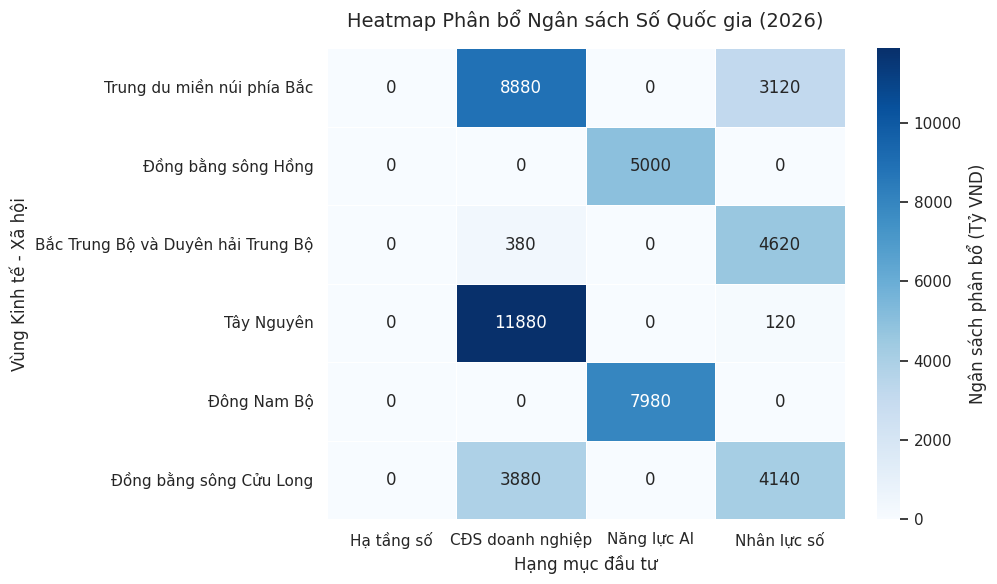

--- DỮ LIỆU PHÂN TÍCH ---
1. Tổng ngân sách nhận được theo từng vùng (Tỷ VND):
Trung du miền núi phía Bắc            12000.0
Tây Nguyên                            12000.0
Đồng bằng sông Cửu Long                8020.0
Đông Nam Bộ                            7980.0
Đồng bằng sông Hồng                    5000.0
Bắc Trung Bộ và Duyên hải Trung Bộ     5000.0
dtype: float64

2. Hạng mục được ưu tiên rót vốn nhiều nhất tại từng vùng:
Trung du miền núi phía Bắc            CĐS doanh nghiệp
Đồng bằng sông Hồng                        Năng lực AI
Bắc Trung Bộ và Duyên hải Trung Bộ         Nhân lực số
Tây Nguyên                            CĐS doanh nghiệp
Đông Nam Bộ                                Năng lực AI
Đồng bằng sông Cửu Long                    Nhân lực số
dtype: object


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Thiết lập kích thước và style cho biểu đồ
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 2. Vẽ Heatmap
# annot=True: Hiển thị con số trên từng ô
# fmt=".0f": Làm tròn số thành số nguyên (bỏ phần thập phân)
# cmap="Blues": Dải màu từ nhạt (ít tiền) đến đậm (nhiều tiền)
sns.heatmap(df_results, annot=True, fmt=".0f", cmap="Blues",
            linewidths=.5, cbar_kws={'label': 'Ngân sách phân bổ (Tỷ VND)'})

# 3. Căn chỉnh tiêu đề và trục
plt.title("Heatmap Phân bổ Ngân sách Số Quốc gia (2026)", fontsize=14, pad=15)
plt.xlabel("Hạng mục đầu tư", fontsize=12)
plt.ylabel("Vùng Kinh tế - Xã hội", fontsize=12)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

# 4. Viết code hỗ trợ trả lời câu hỏi phân tích
print("--- DỮ LIỆU PHÂN TÍCH ---")
# Tính tổng ngân sách mỗi vùng nhận được để xem vùng nào cao nhất
region_totals = df_results.sum(axis=1).sort_values(ascending=False)
print("1. Tổng ngân sách nhận được theo từng vùng (Tỷ VND):")
print(region_totals)

# Tìm hạng mục nhận được nhiều tiền nhất ở mỗi vùng
top_items_per_region = df_results.idxmax(axis=1)
print("\n2. Hạng mục được ưu tiên rót vốn nhiều nhất tại từng vùng:")
print(top_items_per_region)